In [20]:
# RUN THIS CELL FIRST
import math
from collections import OrderedDict

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader
from torchvision import datasets, transforms
from torchvision.transforms import v2

import numpy as np
from numpy import allclose, isclose

from collections.abc import Callable

device = "cuda" if torch.cuda.is_available() else "cpu"
print(device)

cpu


In [21]:
def train_model(model: nn.Module, dataloader: DataLoader, epochs: int = 20):
    """
    Trains the model for a specified number of epochs/iterations
    
    Parameters
    ---------- 
        model: A PyTorch model to be trained
        dataloader : A DataLoader object that provides batches of the training data
        epochs  : Number of epochs, default of 20
        
    Returns
    -------
        The final model and the loss curve (per epoch)
    """

    losses = []

    """ YOUR CODE HERE """
    # 1. set the optimizer's gradients to zero
    # 2. perform a forward pass
    # 3. calculate the loss
    # 4. backpropagate using the loss
    # 5. take an optimizer step to update weights
    optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
    criterion = nn.CrossEntropyLoss()
    """ YOUR CODE END HERE """

    # Set model to training mode. 
    # See (https://stackoverflow.com/questions/60018578/what-does-model-eval-do-in-pytorch) if curious.
    model.train() 
    for i in range(epochs):
        for x_batch, y_batch in dataloader:
            epoch_loss = 0.0
            """ YOUR CODE HERE """
            optimizer.zero_grad()
            outputs = model(x_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            optimizer.step()
            """ YOUR CODE END HERE """
            epoch_loss += loss.item()
        print(f"Epoch {i+1}/{epochs}, Loss: {epoch_loss:.4f}")
        losses.append(epoch_loss)

    return model, losses

In [22]:
T = transforms.Compose([
    transforms.RandomResizedCrop(128, scale=(0.8, 1.0)),

    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(15),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),

    transforms.ToTensor(),

    transforms.RandomErasing(p=0.3),
])

train_set = datasets.ImageFolder("data/assets/", transform=T)
test_set = datasets.ImageFolder("data/assets/", transform=T)

test_loader = torch.utils.data.DataLoader(test_set, batch_size=32)
train_loader = torch.utils.data.DataLoader(train_set, batch_size=32)

Feature batch shape: torch.Size([32, 3, 128, 128])
Labels batch shape: torch.Size([32])


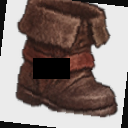

Label: 0
Number of classes: 14


In [23]:
train_features, train_labels = next(iter(train_loader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
display(v2.ToPILImage()(img))
print(f"Label: {label}")

print(f"Number of classes: {len(train_set.classes)}")

In [24]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class CNN(nn.Module):
    def __init__(self, num_classes=14):
        super().__init__()

        def block(in_c, out_c):
            return nn.Sequential(
                nn.Conv2d(in_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.Conv2d(out_c, out_c, 3, padding=1),
                nn.BatchNorm2d(out_c),
                nn.ReLU(),
                nn.MaxPool2d(2)
            )

        self.features = nn.Sequential(
            block(3, 64),
            block(64, 128),
            block(128, 256),
            block(256, 512),
        )

        self.pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)

In [ ]:
%%time

model, losses = train_model(CNN(14), train_loader, epochs = 3)

Epoch 1/3, Loss: 3.1584
